# CLEANIFY PRO : Your Audio, Elevated


# Konversi file audio mp3 ke file audio Wav

Code di bawah berfungsi untuk menginstal library Pydub yang digunakan untuk pengolahan file audio dalam Python. Library ini memungkinkan berbagai manipulasi audio, seperti konversi format file (misalnya dari MP3 ke WAV), pemotongan atau penggabungan klip audio, pengaturan volume, penerapan efek audio, dan perubahan kecepatan.

Selain itu, Pydub juga dapat membaca metadata audio, seperti durasi, frekuensi sampling, dan jumlah saluran. Dengan menginstal Pydub menggunakan perintah ini, Anda dapat dengan mudah melakukan operasi audio kompleks dalam aplikasi berbasis Python.

In [3]:
!pip install pydub

Kode di bawah digunakan untuk mengonversi file audio berformat MP3 menjadi WAV menggunakan library Pydub di Python. Pertama, program mengimpor kelas AudioSegment dari Pydub, yang memungkinkan manipulasi file audio, seperti membuka, mengedit, dan mengonversi format audio. Fungsi utama dalam kode ini adalah convert_mp3_to_wav, yang memiliki dua parameter: input_file (file MP3 yang akan dikonversi) dan output_file (file WAV yang akan dihasilkan). Di dalam fungsi tersebut, AudioSegment.from_file() digunakan untuk membuka file MP3 yang diberikan sebagai input.

Metode ini secara otomatis mendeteksi format file yang akan dibaca, dan dalam hal ini, kita secara eksplisit menyebutkan format "mp3". Setelah audio berhasil dimuat, audio.export() digunakan untuk mengekspor file audio ke format WAV. Fungsi ini menerima dua parameter utama: nama file output dan format yang diinginkan, yaitu "wav". Setelah proses konversi selesai, fungsi menampilkan pesan bahwa file berhasil dikonversi ke format WAV menggunakan fungsi print(). Pada bagian akhir kode, fungsi convert_mp3_to_wav dipanggil dengan file input bernama sada.mp3 dan menghasilkan file output bernama sada.wav. Dengan demikian, kode ini menyederhanakan proses konversi format file audio yang umum digunakan dalam berbagai aplikasi pemrosesan dan analisis audio.


In [4]:
from pydub import AudioSegment

def convert_mp3_to_wav(input_file, output_file):
    audio = AudioSegment.from_file(input_file, format="mp3")
    audio.export(output_file, format="wav")
    print(f"File berhasil dikonversi: {output_file}")

input_mp3 = "sada.mp3"
output_wav = "sada.wav"

convert_mp3_to_wav(input_mp3, output_wav)

File berhasil dikonversi: sada.wav


# Cek Original Audio

Kode di bawah digunakan untuk menganalisis file audio dengan memanfaatkan library Librosa, Matplotlib, dan NumPy. Pertama, file audio "sada.wav" dimuat menggunakan fungsi librosa.load(), yang juga mengembalikan sample rate (sr) dan data audio itu sendiri. Durasi file audio dihitung dengan librosa.get_duration() dan informasi dasar seperti sample rate dan durasi ditampilkan. Selanjutnya, bentuk gelombang sinyal audio divisualisasikan dengan librosa.display.waveshow(), yang menggambarkan perubahan amplitudo sinyal terhadap waktu. Kemudian, transformasi Fourier (FFT) dihitung dengan np.fft.fft(), yang mengubah sinyal dari domain waktu ke domain frekuensi.

Spektrum frekuensi positif diambil dan magnitudo frekuensi dihitung menggunakan np.abs() untuk mendapatkan intensitas pada berbagai frekuensi. Frekuensi dominan, yaitu frekuensi dengan magnitudo tertinggi, ditemukan menggunakan np.argmax() dan ditampilkan. Plot terakhir menunjukkan spektrum frekuensi audio, menggambarkan bagaimana distribusi energi tersebar pada frekuensi tertentu. Terakhir, kode memutar file audio yang dimuat, memungkinkan pengguna untuk mendengarkan audio yang sedang dianalisis. Analisis ini memberikan gambaran tentang karakteristik frekuensi dan komponen utama dalam file audio.

Sample Rate: 44100 Hz
Durasi: 7.45 detik


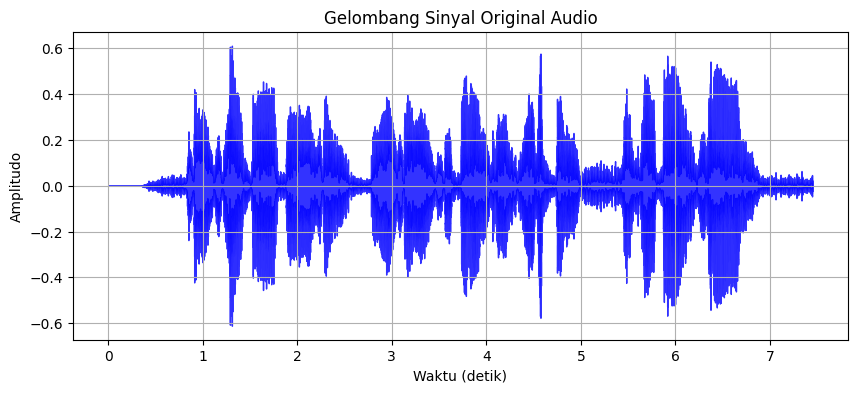

Frekuensi Dominan: 189.84 Hz


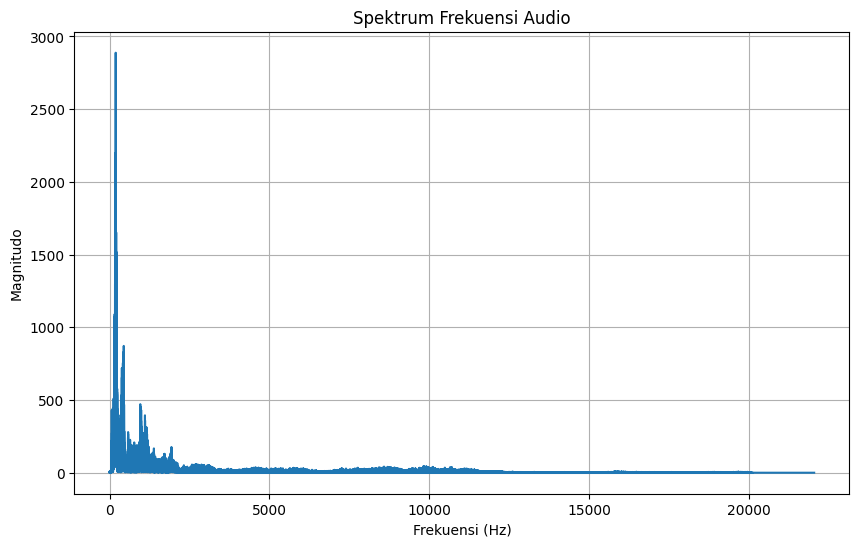

Original Audio:


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

original_file = "sada.wav"
audio, sr = librosa.load(original_file, sr=None)
duration = librosa.get_duration(y=audio, sr=sr)

print(f"Sample Rate: {sr} Hz")
print(f"Durasi: {duration:.2f} detik")

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color='blue', alpha=0.8)
plt.title("Gelombang Sinyal Original Audio")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid()
plt.show()

n = len(audio)
fft_audio = np.fft.fft(audio)
fft_freqs = np.fft.fftfreq(n, d=1/sr)

positive_freqs = fft_freqs[:n//2]
positive_fft = np.abs(fft_audio[:n//2])

dominant_freq = positive_freqs[np.argmax(positive_fft)]
print(f"Frekuensi Dominan: {dominant_freq:.2f} Hz")

plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_fft)
plt.title("Spektrum Frekuensi Audio")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitudo")
plt.grid()
plt.show()

print('Original Audio:')
Audio(original_file)

# Membuat Noise

Kode di bawah dirancang untuk menghasilkan dan menganalisis noise audio dengan rentang frekuensi tertentu. Pertama, parameter dasar ditentukan, seperti sample rate (sr) sebesar 44100 Hz, durasi noise (duration) 7.45 detik, frekuensi dasar (base_freq) 189.84 Hz, frekuensi tambahan (additional_freq) 300 Hz, dan bandwidth noise (noise_bandwidth) 50 Hz. Rentang frekuensi noise dihitung sebagai batas bawah (low_freq) dan batas atas (high_freq) berdasarkan nilai frekuensi tambahan dan bandwidth.

Selanjutnya, white noise dibuat menggunakan fungsi np.random.normal(), yang menghasilkan distribusi Gaussian dengan mean nol. Noise ini kemudian difilter menggunakan filter band-pass digital yang dirancang dengan fungsi signal.butter(). Filter ini dibuat dengan orde 4 dan diimplementasikan dalam bentuk second-order sections (sos) untuk stabilitas numerik. Noise hasil filter dihitung dengan fungsi signal.sosfilt(), yang memastikan hanya noise dalam rentang frekuensi tertentu yang lolos. Noise yang dihasilkan disimpan dalam file WAV menggunakan soundfile.write() dan diberi nama "sada_noise.wav". Kode juga memungkinkan untuk memutar audio noise yang telah dibuat dengan menggunakan IPython.display.Audio().

Gelombang noise divisualisasikan menggunakan Matplotlib dalam domain waktu, menampilkan amplitudo noise terhadap waktu. Untuk analisis lebih lanjut, spektrum frekuensi noise dihitung menggunakan fungsi signal.periodogram(), yang memberikan distribusi daya terhadap frekuensi. Grafik spektrum frekuensi menunjukkan distribusi energi noise, dibatasi hingga 1000 Hz untuk fokus pada frekuensi rendah. Visualisasi ini membantu memahami bagaimana energi noise tersebar di rentang frekuensi tertentu. Kode ini secara keseluruhan memanfaatkan kombinasi metode simulasi, filtering, dan analisis spektral untuk mempelajari karakteristik noise.


Noise tambahan telah disimpan ke file: sada_noise.wav


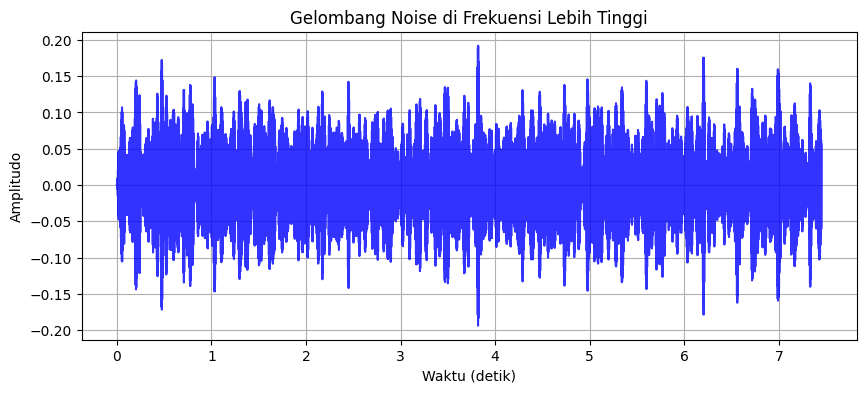

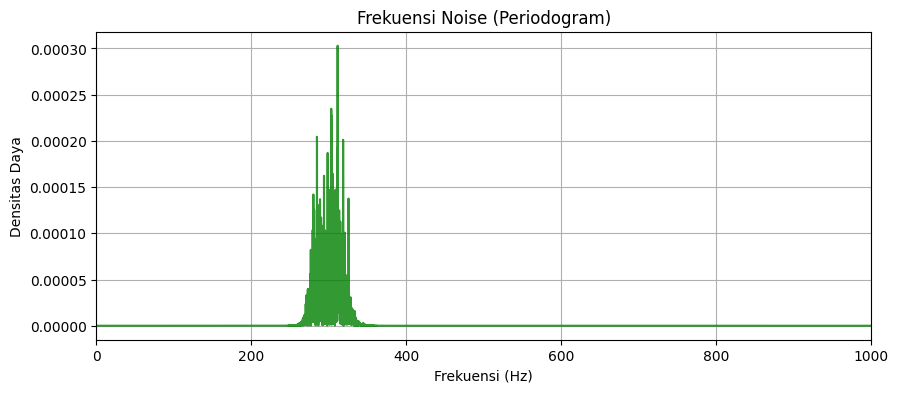

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

sr = 44100
duration = 7.45
base_freq = 189.84
additional_freq = 300
noise_bandwidth = 50

low_freq = additional_freq - noise_bandwidth / 2
high_freq = additional_freq + noise_bandwidth / 2

white_noise = np.random.normal(0, 1, int(sr * duration))

sos = signal.butter(4, [low_freq, high_freq], btype='bandpass', fs=sr, output='sos')
filtered_noise = signal.sosfilt(sos, white_noise)

output_filename = "sada_noise.wav"
sf.write(output_filename, filtered_noise, sr)
print(f"Noise tambahan telah disimpan ke file: {output_filename}")

display(Audio(data=filtered_noise, rate=sr))

plt.figure(figsize=(10, 4))
plt.plot(np.linspace(0, duration, len(filtered_noise)), filtered_noise, color='blue', alpha=0.8)
plt.title("Gelombang Noise di Frekuensi Lebih Tinggi")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid()
plt.show()

frequencies, power_density = signal.periodogram(filtered_noise, sr)

plt.figure(figsize=(10, 4))
plt.plot(frequencies, power_density, color='green', alpha=0.8)
plt.title("Frekuensi Noise (Periodogram)")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Densitas Daya")
plt.xlim(0, 1000)
plt.grid()
plt.show()

# Combine Noise Audio dan Original Audio

Kode di bawah bertujuan untuk menggabungkan dua file audio, yaitu audio asli (sada.wav) dan noise (sada_noise.wav), dengan bobot tertentu, sehingga menghasilkan file audio gabungan (sada_combined.wav). Proses dimulai dengan membaca kedua file audio menggunakan librosa.load() untuk mendapatkan data audio beserta sample rate-nya. Panjang kedua audio disesuaikan dengan memotong audio yang lebih panjang berdasarkan panjang file terpendek. Kemudian, kedua audio digabung menggunakan bobot yang telah ditentukan (weight1 untuk audio asli dan weight2 untuk noise), dengan kombinasi linear: combined_audio=weight1×audio1+weight2×audio2. Hasil gabungan ini dinormalisasi agar amplitudo berada dalam rentang [−1,1], dan disimpan dalam file WAV menggunakan soundfile.write(). Selain itu, kode juga menampilkan visualisasi gelombang sinyal audio asli, noise, dan gabungannya menggunakan matplotlib, untuk memberikan gambaran tentang perubahan karakteristik sinyal. Terakhir, audio gabungan dapat langsung diputar menggunakan IPython.display.Audio() untuk memastikan hasil penggabungan sesuai. Kode ini sangat berguna untuk simulasi pengolahan sinyal audio dengan noise, serta untuk menguji efektivitas metode reduksi noise.

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio

def combine_audio_simple(file1, file2, output_file, weight1=0.5, weight2=0.5):
    audio1, sr1 = librosa.load(file1, sr=None)
    audio2, sr2 = librosa.load(file2, sr=None)

    min_len = min(len(audio1), len(audio2))
    audio1 = audio1[:min_len]
    audio2 = audio2[:min_len]

    combined_audio = weight1 * audio1 + weight2 * audio2
    combined_audio = combined_audio / np.max(np.abs(combined_audio))
    sf.write(output_file, combined_audio, sr1)

    return audio1, audio2, combined_audio, sr1

original_file = "sada.wav"
noise_file = "sada_noise.wav"
output_file = "sada_combined.wav"

audio1, audio2, combined_audio, sr = combine_audio_simple(original_file, noise_file, output_file, weight1=0.7, weight2=0.3)

plt.figure(figsize=(12, 6))
plt.plot(np.linspace(0, len(audio1) / sr, len(audio1)), audio1, color='blue', alpha=0.6, label="Original")
plt.plot(np.linspace(0, len(audio2) / sr, len(audio2)), audio2, color='red', alpha=0.6, label="Noise")
# plt.plot(np.linspace(0, len(combined_audio) / sr, len(combined_audio)), combined_audio, color='green', alpha=0.6, label="Combined")

plt.title("Gelombang Sinyal: Original, Noise, dan Gabungan")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(np.linspace(0, len(combined_audio) / sr, len(combined_audio)), combined_audio, color='purple', alpha=0.8, label="Combined")
plt.title("Gelombang Sinyal: Gabungan")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.legend()
plt.grid()
plt.show()

print('Combined Audio')
Audio(output_file)

# Filtering Noise Audio

Code dibawah digunakan untuk menginstal library noisereduce, yang berfungsi untuk mengurangi noise atau gangguan suara pada sinyal audio menggunakan metode spectral gating. Library ini sangat berguna dalam pemrosesan audio, khususnya untuk meningkatkan kualitas suara dengan menghilangkan noise latar belakang seperti dengungan, suara angin, atau gangguan lainnya. Dengan menginstal noisereduce, pengguna dapat melakukan pembersihan audio untuk kebutuhan rekaman, analisis suara, atau aplikasi real-time, sehingga hasil audio menjadi lebih jernih dan mudah diproses. Library ini ideal untuk berbagai keperluan, mulai dari pengolahan sinyal sederhana hingga proyek yang lebih kompleks seperti pengenalan suara atau pembuatan podcast.

In [ ]:
!pip install noisereduce

Kode di bawah bertujuan untuk meningkatkan kualitas audio dengan tiga langkah utama, yaitu noise reduction, filtering, dan penyesuaian amplitudo. Pertama, audio yang berisi sinyal campuran (original + noise) dimuat menggunakan librosa. Kemudian, bagian awal audio selama durasi tertentu (default 1 detik) digunakan sebagai sampel noise, dan noise reduction diterapkan menggunakan library noisereduce untuk mengurangi komponen noise pada audio. Setelah noise berkurang, dilakukan proses filtering menggunakan FIR (Finite Impulse Response) low-pass filter dari scipy.signal.firwin dan lfilter. Filter ini memblokir frekuensi di atas batas tertentu (default 200 Hz), sehingga komponen frekuensi tinggi yang cenderung berupa noise dapat dihilangkan. Selanjutnya, amplitudo audio yang telah difilter diperkuat dengan menyesuaikan RMS (Root Mean Square) agar audio menjadi lebih nyaring.
Hasil akhir audio yang sudah diperbaiki kemudian disimpan menggunakan soundfile dan divisualisasikan dalam tiga grafik: audio gabungan asli, audio setelah noise reduction dan filtering, serta audio akhir dengan penyesuaian amplitudo. Setiap langkah dilengkapi dengan audio playback agar pengguna dapat mendengar perbedaannya secara langsung.


In [ ]:
import librosa
import noisereduce as nr
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
from IPython.display import Audio, display

def apply_fir_filter(audio, sr, cutoff=200):
    nyquist = sr / 2
    numtaps = 1
    fir_coeff = firwin(numtaps, cutoff / nyquist, pass_zero=True)
    filtered_audio = lfilter(fir_coeff, [1.0], audio)
    return filtered_audio

def enhance_audio_with_filter(audio, sr, noise_duration=1.0, cutoff=200):
    noise_clip = audio[:int(noise_duration * sr)]
    audio_denoised = nr.reduce_noise(y=audio, sr=sr, y_noise=noise_clip)

    audio_filtered = apply_fir_filter(audio_denoised, sr, cutoff=cutoff)

    rms = np.sqrt(np.mean(audio_filtered**2))
    target_rms = rms * 3
    gain_factor = target_rms / rms
    audio_enhanced = audio_filtered * gain_factor

    return audio_enhanced

audio, sr = librosa.load('sada_combined.wav', sr=None)
audio_enhanced = enhance_audio_with_filter(audio, sr, noise_duration=1.0, cutoff=200)
sf.write('sada_hasil.wav', audio_enhanced, sr)

plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0, len(audio) / sr, len(audio)), audio, color='purple', alpha=0.6, label="Combined Audio")
plt.title("Gelombang Sinyal Original Audio dan Noise Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
display(Audio(data=audio, rate=sr))

plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0, len(audio_enhanced) / sr, len(audio_enhanced)), audio_enhanced, color='rebeccapurple', alpha=0.8, label="Enhanced Audio (Noise Reduced & Filtered)")
plt.title("Enhanced Audio with Noise Reduction and Low-Pass Filter")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
display(Audio(data=audio_enhanced, rate=sr))

plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0, len(audio_enhanced) / sr, len(audio_enhanced)), audio_enhanced, color='green', alpha=1.0, label="Final Enhanced Audio")
plt.title("Final Enhanced Audio (Noise Reduced, Filtered & Louder)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
display(Audio(data=audio_enhanced, rate=sr))

# Perbandingan Gelombang Sinyal Original Audio dan Hasil Filtering

Kode di bawah membandingkan audio original dan audio hasil filtering melalui visualisasi grafik dan playback audio. Visualisasi pertama menampilkan dua subplot: grafik kiri menunjukkan audio original berwarna biru, yang masih mengandung noise dengan amplitudo yang kacau, sedangkan grafik kanan menampilkan audio hasil filtering berwarna hijau, yang telah melalui proses noise reduction, low-pass filtering, dan amplifikasi, sehingga sinyal menjadi lebih bersih dan stabil. Selanjutnya, kedua audio diputar untuk memberikan perbandingan auditori, di mana audio original terdengar lebih berisik akibat noise, sedangkan audio hasil filtering terdengar lebih jernih dan nyaman didengar.

Grafik terakhir meng-overlay kedua sinyal dalam satu plot, dengan warna biru mewakili audio original dan warna hijau untuk audio hasil filtering. Perbedaan signifikan terlihat jelas, di mana sinyal hasil filtering memiliki noise yang berkurang drastis dan amplitudo yang lebih konsisten dibandingkan audio asli. Secara keseluruhan, output ini menunjukkan keberhasilan proses filtering dalam meningkatkan kualitas audio dengan mengurangi noise dan mempertajam sinyal utama.


In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

original_audio, sr_original = librosa.load('sada.wav', sr=None)
enhanced_audio, sr_enhanced = librosa.load('sada_hasil.wav', sr=None)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, len(original_audio) / sr_original, len(original_audio)), original_audio, color='blue', alpha=0.6, label="Original Audio")
plt.title("Original Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(np.linspace(0, len(enhanced_audio) / sr_enhanced, len(enhanced_audio)), enhanced_audio, color='green', alpha=0.8, label="Enhanced Audio")
plt.title("Final Filtering Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print('Original Audio')
display(Audio(data=original_audio, rate=sr_original))
print('Filtering Audio')
display(Audio(data=enhanced_audio, rate=sr_enhanced))

plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0, len(original_audio) / sr_original, len(original_audio)), original_audio, color='blue', alpha=0.6, label="Original Audio")
plt.plot(np.linspace(0, len(enhanced_audio) / sr_enhanced, len(enhanced_audio)), enhanced_audio, color='green', alpha=0.6, label="Filtering Audio")

plt.title("Original and Filtering Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Perbandingan Korelasi Original Audio dan Hasil Filtering

Kode ini digunakan untuk membandingkan dua file audio, yaitu audio asli dan audio hasil filtering, dengan tujuan untuk menilai seberapa efektif proses filtering dalam mengurangi noise dan mempertahankan kualitas sinyal. Pertama, kedua file audio dimuat dan dinormalisasi, yaitu amplitudo setiap sinyal disesuaikan agar berada dalam rentang -1 hingga 1. Setelah itu, panjang kedua audio disesuaikan untuk memastikan perhitungan statistik dilakukan pada segmen yang setara. Perbandingan dilakukan dengan menghitung Mean Squared Error (MSE), yang mengukur perbedaan antara kedua sinyal, dan koefisien korelasi, yang menunjukkan tingkat kesamaan bentuk gelombang antara audio asli dan hasil filtering.

Nilai MSE yang lebih rendah dan korelasi yang lebih tinggi menandakan bahwa hasil filtering sangat mirip dengan audio asli. Visualisasi gelombang audio juga disediakan untuk mempermudah analisis perbedaan antara kedua sinyal. Selain itu, nilai rata-rata dan standar deviasi untuk masing-masing audio dihitung dan ditampilkan. Hasil dari perhitungan ini memberikan wawasan kuantitatif tentang seberapa baik proses filtering dalam mempertahankan kualitas audio asli sambil mengurangi noise.


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def resample_audio(audio, sr, target_sr):
    return librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

def normalize_audio(audio):
    return audio / np.max(np.abs(audio))

def compare_audio_files(file1, file2):
    audio1, sr1 = librosa.load(file1, sr=None)
    audio2, sr2 = librosa.load(file2, sr=None)

    audio1 = normalize_audio(audio1)
    audio2 = normalize_audio(audio2)

    min_len = min(len(audio1), len(audio2))
    audio1, audio2 = audio1[:min_len], audio2[:min_len]

    mse = mean_squared_error(audio1, audio2)

    correlation = np.corrcoef(audio1, audio2)[0, 1]

    plt.figure(figsize=(10, 5))
    plt.plot(audio1, label="Original Audio", alpha=0.7)
    plt.plot(audio2, label="Filtered Audio", alpha=0.7)
    plt.legend()
    plt.title("Waveform Comparison")
    plt.show()

    print(f"Audio1 Mean: {np.mean(audio1):.5f}, Std: {np.std(audio1):.5f}")
    print(f"Audio2 Mean: {np.mean(audio2):.5f}, Std: {np.std(audio2):.5f}")

    return mse, correlation

original_file = 'sada.wav'
filtered_file = 'sada_hasil.wav'

mse, correlation = compare_audio_files(original_file, filtered_file)

print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Korelasi: {correlation:.5f}")
